<a href="https://colab.research.google.com/github/LeoTungAnh/Morden-Computer-Vision-with-Pytorch-v2/blob/main/Reinforcement_Learning/Proximal_Gradient_Method_CartPole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook implements the REINFORCE (Policy Gradient) algorithm, inspired by the article: [REINFORCE: A Policy Gradient-Based Reinforcement Learning Algorithm](https://medium.com/intro-to-artificial-intelligence/reinforce-a-policy-gradient-based-reinforcement-learning-algorithm-84bde440c816).

## 1. Deep Q-Learning vs Policy Gradient

- Deep Q-Learning (DQN) learns a value function `Q(s, a)` and selects actions using `argmax`, leading to a typically deterministic policy. This cannot be applied to continuous action space. Because of this, we use policy which can be used in continuous action space.
- Policy Gradient (PG) directly learns the policy `π(a | s)`, which is inherently stochastic and optimized via gradient ascent on expected reward.  

**Summary:**  
- DQN = learn values → derive policy  
- PG = learn policy directly  

---

## 2. Monte Carlo vs TD vs Dynamic Programming

- Monte Carlo (MC): learns from full episodes → unbiased but high variance.  
- Temporal Difference (TD): learns step-by-step (bootstrapping) → lower variance, faster but biased.  
- Dynamic Programming (DP): requires a full environment model (known transitions) → exact updates but impractical in real-world RL.  

**Summary:**  
- MC = wait until episode ends  
- TD = learn online  
- DP = requires full model  
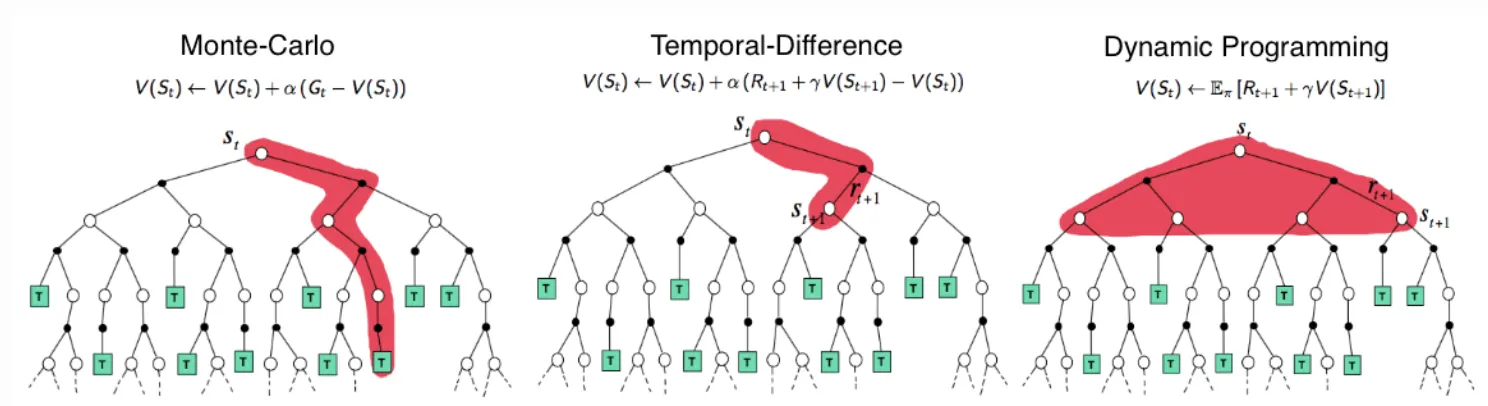

Here's a high-level pseudo-code for the REINFORCE algorithm:

```
Initialize Policy Network and Optimizer
Set discount factor (gamma)

For each episode:
  Generate an episode trajectory (states, actions, rewards, log_probs)
  
  Calculate discounted returns (G_t) for each step in the trajectory
  Normalize returns (optional)
  
  Calculate policy loss using log_probs and returns: loss = -sum(log_prob * G_t)
  
  Perform backpropagation to compute gradients
  Update Policy Network weights using the optimizer
  
  (Optional) Log episode reward

Close environment
(Optional) Plot episode rewards
```

In [29]:
!pip install gymnasium

In [30]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import torch.nn.functional as F

In [31]:
class PolicyNet(nn.Module):
  def __init__(self, state_dim, hidden_dim, action_dim):
    super().__init__()
    self.linear1 = nn.Linear(state_dim, hidden_dim)
    self.linear2 = nn.Linear(hidden_dim, action_dim)
  def forward(self, x):
    x = self.linear1(x)
    x = F.relu(x)
    x = self.linear2(x)
    return F.softmax(x, dim=-1)

In [32]:
def compute_returns(rewards, gamma):
  returns = []
  G = 0.0
  for r in reversed(rewards):
    G = r + gamma*G
    returns.insert(0, G)
  return returns

In [33]:
env = gym.make('CartPole-v1')

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy = PolicyNet(state_dim, hidden_dim=128, action_dim=action_dim)
optimizer = optim.Adam(policy.parameters(), lr=1e-3)

gamma = 0.99
num_episodes = 2000

episode_rewards = []

for episode in range(num_episodes):
  state, *_ = env.reset()
  log_probs = []
  rewards = []
  done = False
  truncated = False
  total_reward = 0.0

  while not (done or truncated):
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0) # Add batch dimension
    probs = policy(state_tensor)
    prob_distribution = Categorical(probs)
    action = prob_distribution.sample()
    log_prob = prob_distribution.log_prob(action)
    next_state, reward, done, truncated, _ = env.step(int(action.item()))
    log_probs.append(log_prob)
    rewards.append(reward)
    total_reward += reward
    state = next_state
  returns = compute_returns(rewards, gamma)
  returns = torch.tensor(returns, dtype=torch.float32)
  returns = (returns - returns.mean()) / (returns.std() + 1e-9)
  loss = 0.0
  for log_prob, return_ in zip(log_probs, returns):
    loss += -log_prob * return_
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  episode_rewards.append(total_reward) # Store total reward

  if (episode + 1) % 100 == 0:
    print(f"Episode {episode+1}, total_reward = {total_reward}")
env.close()

Episode 100, total_reward = 35.0
Episode 200, total_reward = 44.0
Episode 300, total_reward = 184.0
Episode 400, total_reward = 234.0
Episode 500, total_reward = 192.0
Episode 600, total_reward = 500.0
Episode 700, total_reward = 500.0
Episode 800, total_reward = 499.0
Episode 900, total_reward = 500.0
Episode 1000, total_reward = 500.0
Episode 1100, total_reward = 500.0
Episode 1200, total_reward = 500.0
Episode 1300, total_reward = 500.0
Episode 1400, total_reward = 500.0
Episode 1500, total_reward = 500.0
Episode 1600, total_reward = 500.0
Episode 1700, total_reward = 500.0
Episode 1800, total_reward = 500.0
Episode 1900, total_reward = 500.0
Episode 2000, total_reward = 500.0


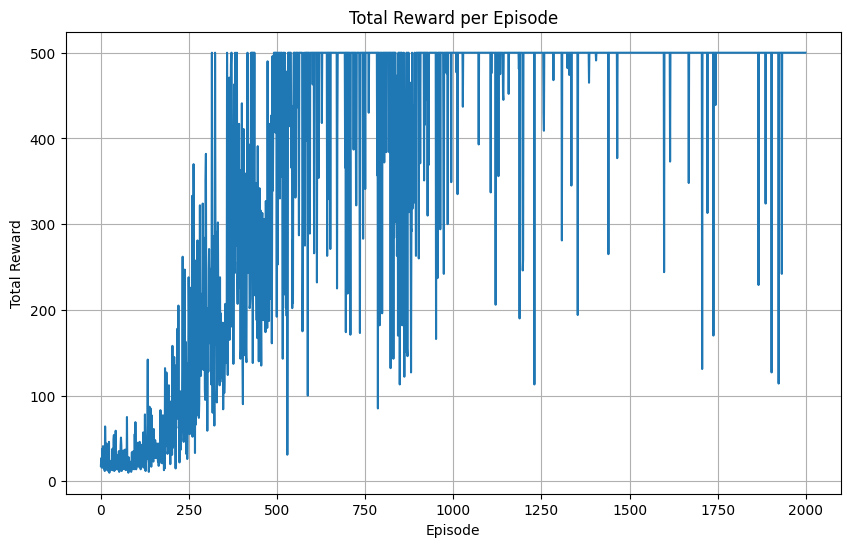

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Total Reward per Episode')
plt.grid(True)
plt.show()